In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re

warnings.filterwarnings('ignore')

from sklearn.naive_bayes import MultinomialNB
from sklearn.multiclass import OneVsRestClassifier
from sklearn import metrics
from sklearn.metrics import accuracy_score
from pandas.plotting import scatter_matrix
from sklearn.neighbors import KNeighborsClassifier


In [ ]:
resumeDataset = pd.read_csv('/content/UpdatedResumeDataSet.csv',encoding='utf-8')
resumeDataset['cleaned_resume']=''
resumeDataset.head()


,Category,Resume,cleaned_resume
0,Data Science,Skills * Programming Languages: Python (pandas...,
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...,
2,Data Science,"Areas of Interest Deep Learning, Control Syste...",
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab...",


In [ ]:
print("Displaying the distinct categories of resume -")
print(resumeDataset['Category'].unique())

Displaying the distinct categories of resume -
['Data Science' 'HR' 'Advocate' 'Arts' 'Web Designing'
 'Mechanical Engineer' 'Sales' 'Health and fitness' 'Civil Engineer'
 'Java Developer' 'Business Analyst' 'SAP Developer' 'Automation Testing'
 'Electrical Engineering' 'Operations Manager' 'Python Developer'
 'DevOps Engineer' 'Network Security Engineer' 'PMO' 'Database' 'Hadoop'
 'ETL Developer' 'DotNet Developer' 'Blockchain' 'Testing']


In [ ]:
print("Displaying the distinct categories of resume and number of recods  belonging to each category.")
print(resumeDataset['Category'].value_counts())

Displaying the distinct categories of resume and number of recods  belonging to each category.
Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Sales                        40
Data Science                 40
Mechanical Engineer          40
ETL Developer                40
Blockchain                   40
Operations Manager           40
Arts                         36
Database                     33
Health and fitness           30
PMO                          30
Electrical Engineering       30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64


#**visualize  the  number  of data set**

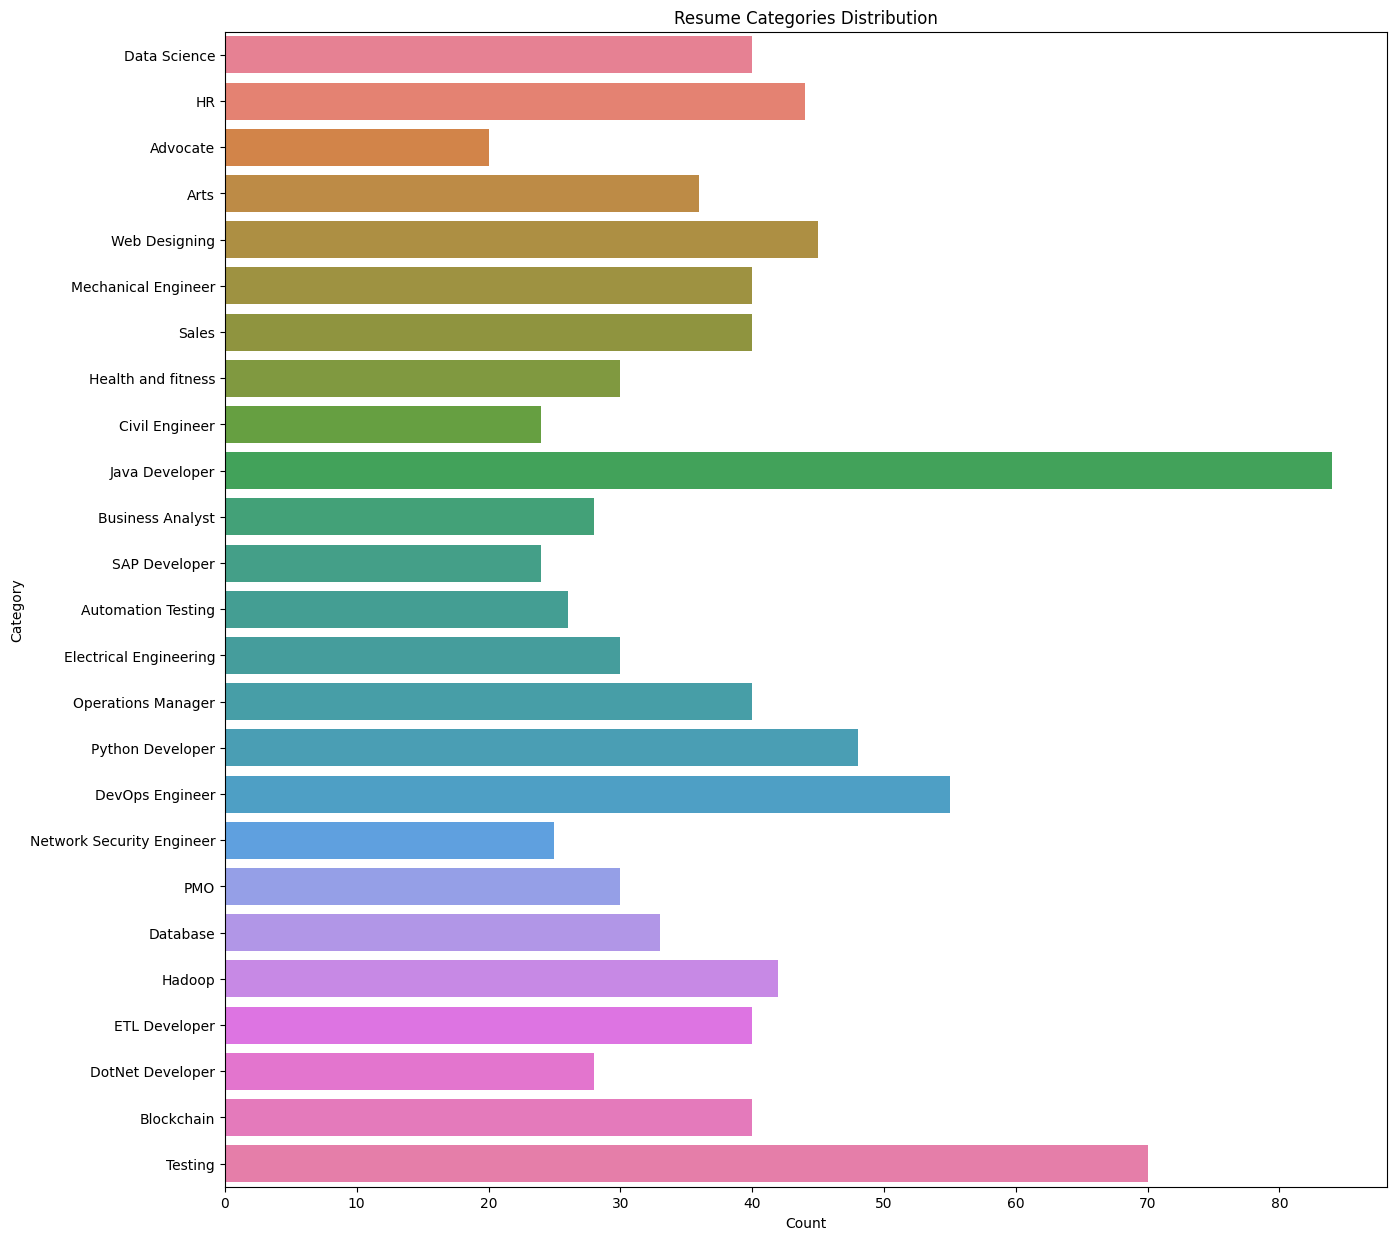

In [ ]:
plt.figure(figsize=(15,15))
sns.countplot(y="Category", data=resumeDataset, palette="husl")

plt.title("Resume Categories Distribution")
plt.xlabel("Count")
plt.ylabel("Category")

plt.show()


#Visualize  the distribution of categories


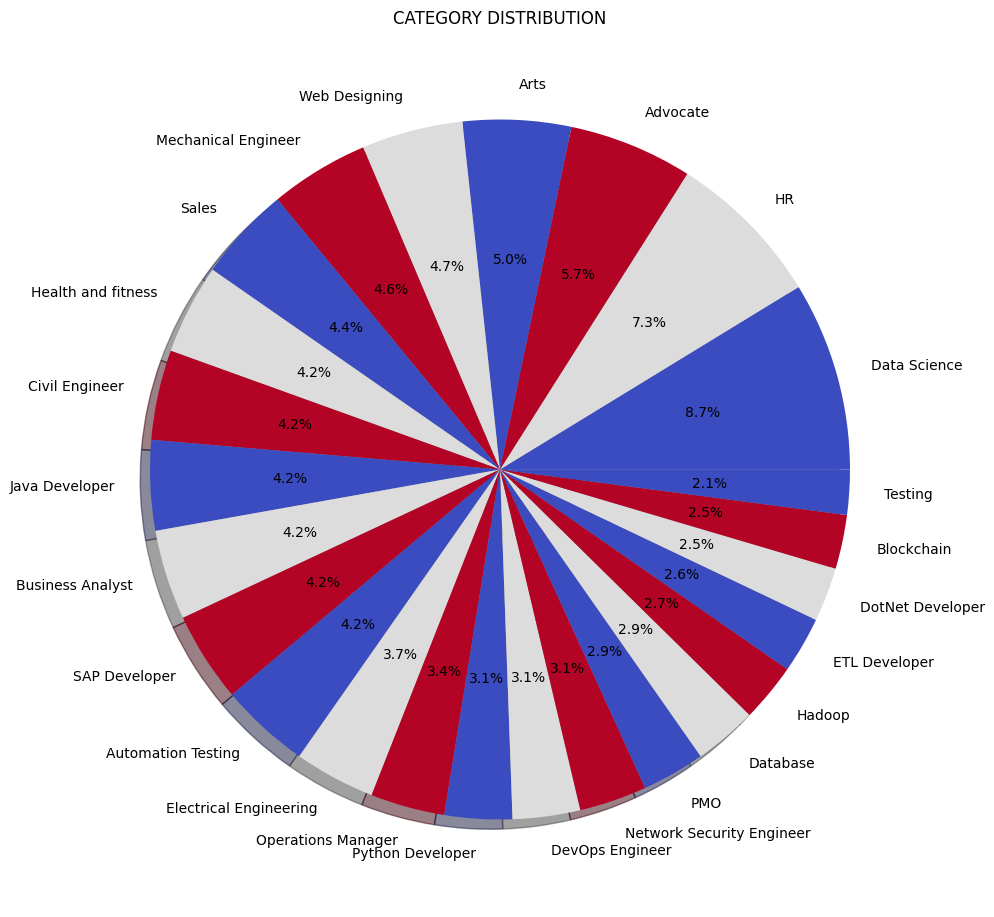

In [ ]:
from matplotlib.gridspec import GridSpec
targetCounts = resumeDataset['Category'].value_counts()
targetLabels = resumeDataset['Category'].unique()
#Make square figures and axes
plt.figure(1,figsize=(25,25))
the_grid = GridSpec(2,2)

cmap = plt.get_cmap('coolwarm')
colors = [cmap(i) for i in np.linspace(0,1,3)]
plt.subplot(the_grid[0,1],aspect = 1 ,title = 'CATEGORY DISTRIBUTION')

source_pie = plt.pie(targetCounts,labels = targetLabels,autopct = '%1.1f%%',shadow = True,colors = colors)
plt.show()

In [ ]:
def cleanResume(resumeText):

    resumeText = re.sub('http\S+\s*', '', resumeText)  # remove URLS

    resumeText = re.sub('RT|cc', '', resumeText)  # remove RT and cc

    resumeText = re.sub('#\S+', '', resumeText)  # remove hashtags

    resumeText = re.sub('@\S+', '', resumeText)  # remove mentions

    resumeText = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_^{|}~"""), '', resumeText)  # remove punctuations

    resumeText = re.sub(r'[^\x00-\x7f]', r'', resumeText)

    resumeText = re.sub('\s+', '', resumeText)  # remove extra whitespace

    return resumeText


resumeDataset['cleaned_resume'] = resumeDataset.Resume.apply(lambda x: cleanResume(x))
resumeDataSet['cleaned_resume'] = resumeDataSet['Resume'].apply(cleanResume)




In [11]:
pip install wordcloud


In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Index(['Category', 'Resume'], dtype='object')

Top 50 Words:

[('â\x80¢', 12213), ('Exprience', 3829), ('months', 3233), ('company', 3116), ('Details', 2967), ('description', 2634), ('1', 1865), ('Project', 1701), ('project', 1521), ('data', 1434), ('team', 1405), ('Maharashtra', 1385), ('6', 1369), ('year', 1240), ('Less', 1137), ('January', 1086), ('using', 1041), ('Skill', 1012), ('Pune', 1009), ('Management', 959), ('management', 927), ('â\x9e¢', 908), ('SQL', 841), ('Engineering', 835), ("'s", 813), ('Developer', 786), ('monthsCompany', 746), ('Ltd', 746), ('development', 738), ('application', 727), ('Pvt', 712), ('System', 705), ('Java', 704), ('reports', 697), ('business', 696), ('various', 688), ('requirements', 685), ('India', 669), ('Education', 654), ('Data', 647), ('University', 645), ('The', 641), ('test', 638), ('Responsibilities', 637), ('testing', 634), ('process', 627), ('Software', 627), ('Technologies', 622), ('work', 622), ('Testing', 610)]


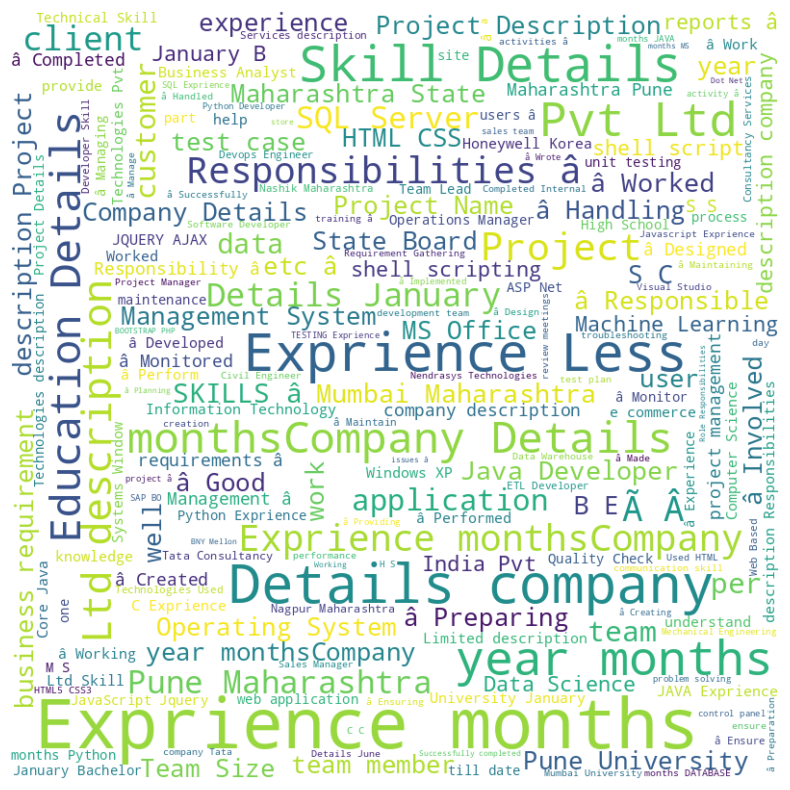

In [ ]:
# Install & Import Libraries
import nltk
import pandas as pd
import string
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from wordcloud import WordCloud

# Download required NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')   # important fix
nltk.download('stopwords')

# Load Dataset
resumeDataSet = pd.read_csv("/content/UpdatedResumeDataSet.csv")

# Check columns (optional but useful)
print(resumeDataSet.columns)

# Stopwords
oneSetOfStopWords = set(stopwords.words('english') + ['``', "''"])

# Function to clean resume (basic version)
def cleanResume(text):
    return str(text)

# Initialize variables
totalWords = []
cleanedSentences = ""

# Extract Resume column
Sentences = resumeDataSet['Resume'].values

# Process text
for i in range(len(Sentences)):
    cleanedText = cleanResume(Sentences[i])
    cleanedSentences += cleanedText

    requiredWords = nltk.word_tokenize(cleanedText)

    for word in requiredWords:
        if word not in oneSetOfStopWords and word not in string.punctuation:
            totalWords.append(word)

# Frequency Distribution
wordfreqdist = nltk.FreqDist(totalWords)
mostcommon = wordfreqdist.most_common(50)

print("\nTop 50 Words:\n")
print(mostcommon)

# Generate WordCloud
wc = WordCloud(width=800, height=800, background_color='white').generate(cleanedSentences)

plt.figure(figsize=(10, 10))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

var_mod = ['Category']
le = LabelEncoder()
for i in var_mod:
    resumeDataSet[i] = le.fit_transform(resumeDataSet[i])

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
resumeDataSet = pd.read_csv('/content/UpdatedResumeDataSet.csv')

requiredText = resumeDataSet['Resume'].values
requiredTarget = resumeDataSet['Category'].values

word_vectorizer = TfidfVectorizer(
    sublinear_tf=True,
    stop_words='english',
    max_features=1500
)

word_vectorizer.fit(requiredText)
WordFeatures = word_vectorizer.transform(requiredText)

print("Feature completed .....")

X_train, X_test, y_train, y_test = train_test_split(
    WordFeatures, requiredTarget, random_state=0, test_size=0.2
)

print(X_train.shape)
print(X_test.shape)

Feature completed .....
(769, 1500)
(193, 1500)


In [10]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics

# =========================
#  KNN MODEL
# =========================
knn_clf = OneVsRestClassifier(KNeighborsClassifier())
knn_clf.fit(X_train, y_train)

knn_pred = knn_clf.predict(X_test)

print("===== KNN CLASSIFIER =====")
print('Training Accuracy: {:.2f}'.format(knn_clf.score(X_train, y_train)))
print('Test Accuracy: {:.2f}'.format(knn_clf.score(X_test, y_test)))

print("\nClassification Report (KNN):\n")
print(metrics.classification_report(y_test, knn_pred))


# =========================
# 🟢 NAIVE BAYES MODEL
# =========================
nb_clf = OneVsRestClassifier(MultinomialNB())
nb_clf.fit(X_train, y_train)

nb_pred = nb_clf.predict(X_test)

print("\n\n===== NAIVE BAYES CLASSIFIER =====")
print('Training Accuracy: {:.2f}'.format(nb_clf.score(X_train, y_train)))
print('Test Accuracy: {:.2f}'.format(nb_clf.score(X_test, y_test)))

print("\nClassification Report (Naive Bayes):\n")
print(metrics.classification_report(y_test, nb_pred))

===== KNN CLASSIFIER =====
Training Accuracy: 1.00
Test Accuracy: 0.99

Classification Report (KNN):

                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         3
                     Arts       1.00      1.00      1.00         3
       Automation Testing       1.00      0.80      0.89         5
               Blockchain       1.00      1.00      1.00         9
         Business Analyst       1.00      1.00      1.00         6
           Civil Engineer       0.83      1.00      0.91         5
             Data Science       1.00      1.00      1.00         9
                 Database       1.00      1.00      1.00         7
          DevOps Engineer       1.00      0.91      0.95        11
         DotNet Developer       1.00      1.00      1.00         9
            ETL Developer       1.00      1.00      1.00         8
   Electrical Engineering       0.90      1.00      0.95         9
                       HR 

In [12]:
nb_clf = OneVsRestClassifier(MultinomialNB())
nb_clf.fit(X_train, y_train)

OneVsRestClassifier(estimator=MultinomialNB())

In [13]:
def predict_resume(text):
    text_vector = word_vectorizer.transform([text])   # convert text to numbers
    prediction = nb_clf.predict(text_vector)          # use trained model
    return prediction[0]

print(predict_resume("Python machine learning data analysis"))

Data Science
